# Sesión 3 – Aplicación de Algoritmos Genéticos a Problemas Reales
## El Problema del Viajero (TSP)
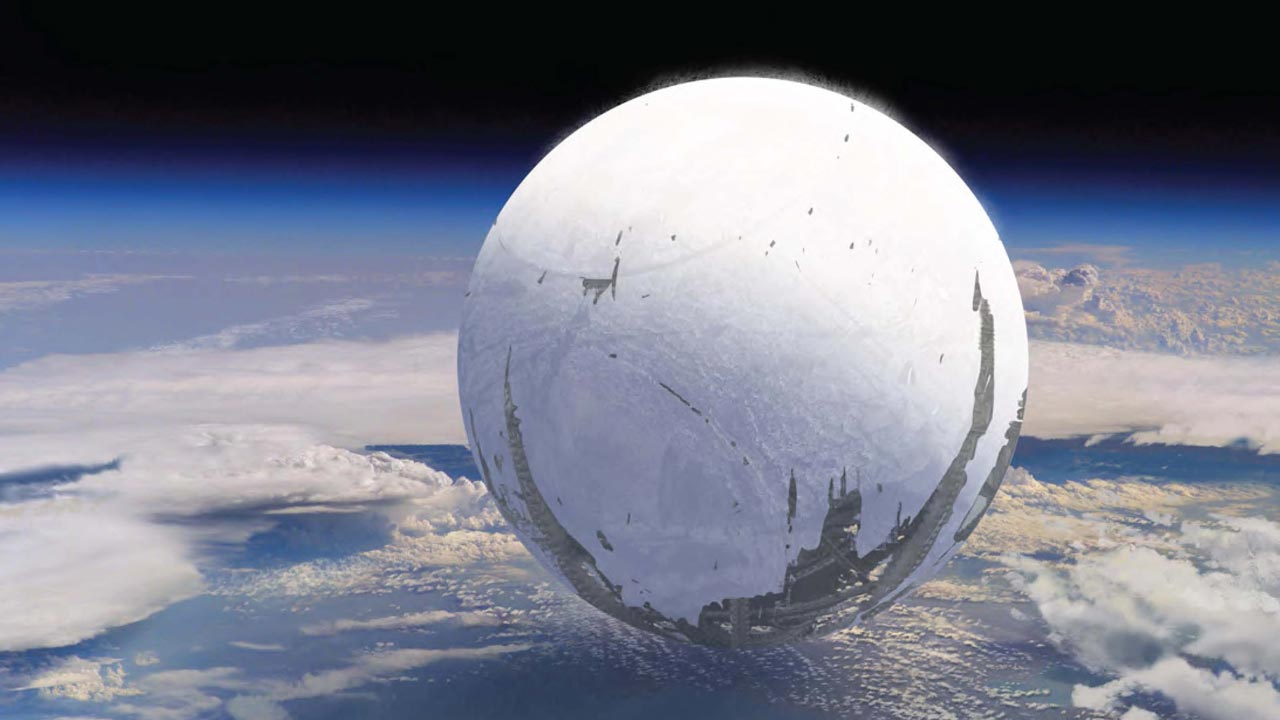



## 1. ¿Qué es el Problema del Viajero?

El **Problema del Viajero (Travelling Salesman Problem, TSP)** consiste en encontrar el recorrido más corto que permita visitar todas las ciudades exactamente una vez y regresar al punto de partida.

Es un problema clásico, ampliamente estudiado, y aparece en logística, planificación y optimización.

### Complejidad del problema

El número de rutas posibles crece factorialmente con el número de ciudades, lo que hace inviable probar todas las soluciones posibles. Por ello se recurre a heurísticas como los algoritmos genéticos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


## 2. Representación de las soluciones

Una solución al TSP es un **orden de visita de las ciudades**. Por ello, cada individuo del algoritmo genético se representa como una **permutación** de índices de ciudades.

In [2]:
num_ciudades = 8
ciudades = np.random.rand(num_ciudades, 2)
ciudades


array([[0.41705886, 0.82200798],
       [0.80675254, 0.32575495],
       [0.43958403, 0.33898097],
       [0.88215744, 0.8529351 ],
       [0.49794184, 0.76917111],
       [0.60545931, 0.09585354],
       [0.89388298, 0.85089301],
       [0.13258014, 0.86840146]])

Representamos gráficamente las citudades en el *plano*.

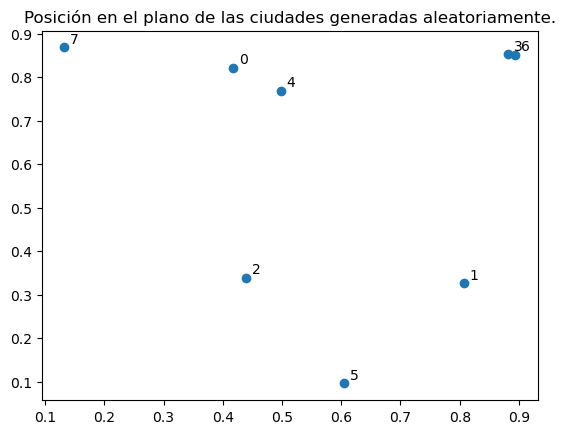

In [3]:
delta = 0.01 # Desplazamiento de la etiqueta sobre las coordenadas del punto. 
fig, ax = plt.subplots()

plt.title("Posición en el plano de las ciudades generadas aleatoriamente.")
ax.scatter(ciudades[:,0], ciudades[:,1])

etiquetas = range(num_ciudades)

for i,punto in enumerate(ciudades):
    ax.annotate(etiquetas[i], xy = (punto[0] + delta, punto[1] + delta))

## 3. Variables del problema

- Cada ciudad se representa como un punto en el plano.
- La distancia entre ciudades se calcula con la distancia euclídea.
- El objetivo es minimizar la distancia total recorrida.

## 4. Función de fitness

La función de fitness mide la calidad de una ruta. En este problema, cuanto menor sea la distancia total, mejor será la solución.

In [4]:
def distancia_total(ruta, ciudades):
    dist = 0
    for i in range(len(ruta)):
        a = ciudades[ruta[i]]
        b = ciudades[ruta[(i+1)%len(ruta)]]
        dist += np.linalg.norm(a-b)
    return dist


## 5. Población inicial

La población inicial se genera aleatoriamente. Cada individuo es una permutación válida, lo que garantiza soluciones correctas desde el inicio.

In [5]:
def poblacion_inicial(n, num_ciudades):
    return [np.random.permutation(num_ciudades) for _ in range(n)]

N = 50
poblacion = poblacion_inicial(N, num_ciudades)


## 6. Selección por torneo

La selección por torneo elige al mejor individuo dentro de un subconjunto aleatorio de la población, equilibrando explotación y diversidad.

In [6]:
def seleccion_torneo(poblacion, ciudades, k=3):
    participantes = random.sample(poblacion, k)
    participantes.sort(key=lambda r: distancia_total(r, ciudades))
    return participantes[0]


## 7. Cruce por orden (OX)

El cruce OX es un operador específico para permutaciones que combina información de dos padres sin generar rutas inválidas.

In [7]:
def cruce_ox(p1, p2):
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))
    hijo = [-1]*size
    hijo[a:b] = p1[a:b]
    pos = b
    '''
    print("Para los padres:")
    print("P1: " + str(p1))
    print("P2: " + str(p2))
    print("a y b: " + str(a)  + str(b))
    '''
    for gene in p2:
        if gene not in hijo:
            if pos >= size:
                pos = 0
            hijo[pos] = gene
            pos += 1
    # print("El hijo: "+ str(hijo))
    return np.array(hijo)


## 8. Mutación por intercambio

La mutación introduce variación genética intercambiando dos ciudades de la ruta, manteniendo la validez de la solución.

In [8]:
def mutacion_swap(ruta, p=0.2):
    ruta = ruta.copy()
    if random.random() < p:
        i, j = random.sample(range(len(ruta)), 2)
        ruta[i], ruta[j] = ruta[j], ruta[i]
    return ruta


## 9. Bucle evolutivo

El algoritmo genético repite selección, cruce y mutación durante varias generaciones para mejorar progresivamente las soluciones.

In [9]:
generaciones = 5000
mejor_dist = []

for g in range(generaciones):
    nueva_poblacion = []
    for _ in range(N):
        p1 = seleccion_torneo(poblacion, ciudades)
        p2 = seleccion_torneo(poblacion, ciudades)
        hijo = cruce_ox(p1, p2)
        hijo = mutacion_swap(hijo)
        nueva_poblacion.append(hijo)
    poblacion = nueva_poblacion
    mejor = min(poblacion, key=lambda r: distancia_total(r, ciudades))
    mejor_dist.append(distancia_total(mejor, ciudades))


## 10. Análisis de resultados

La gráfica final muestra cómo disminuye la distancia total a lo largo de las generaciones, reflejando la convergencia del algoritmo genético.

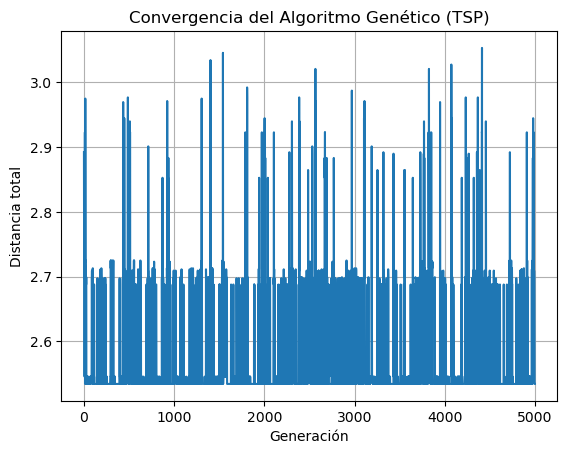

El valor mínimo de la distancia es 2.5341959848210367


In [10]:
plt.plot(mejor_dist)
plt.xlabel('Generación')
plt.ylabel('Distancia total')
plt.title('Convergencia del Algoritmo Genético (TSP)')
plt.grid(True)
plt.show()
print(f"El valor mínimo de la distancia es {np.min(mejor_dist)}")




Si lo que pretendemos es obtener las rutas con mejores resultados:

In [11]:
generaciones = 1000
mejor_dist = []
distancia_minima = 999999999
soluciones = []

for g in range(generaciones):
    nueva_poblacion = []
    for _ in range(N):
        p1 = seleccion_torneo(poblacion, ciudades)
        p2 = seleccion_torneo(poblacion, ciudades)
        hijo = cruce_ox(p1, p2)
        hijo = mutacion_swap(hijo)
        distancia_hijo = distancia_total(hijo,ciudades)
        
        if distancia_hijo == distancia_minima:
            soluciones.append(hijo)
        elif distancia_hijo < distancia_minima:
            distancia_minima = distancia_hijo 
            soluciones = []
            soluciones.append(hijo)

print(f"La distancia mínima entre ciudades es de {distancia_minima:.5f} para las siguientes combinaciones de ciudades: ")
print("Las soluciones únicas son:")
print(np.unique(soluciones, axis= 0))
    



La distancia mínima entre ciudades es de 2.53420 para las siguientes combinaciones de ciudades: 
Las soluciones únicas son:
[[0 4 3 6 1 5 2 7]
 [2 5 1 6 3 4 0 7]
 [6 3 4 0 7 2 5 1]
 [7 2 5 1 6 3 4 0]]
